In [2]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import corner
import emcee
import scipy
import random
import sys
import time
import neuralop
import matplotlib.pyplot as plt
# # import  settings

sys.path.append('..')
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'sim_PyBaMM' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/NO/../sim_PyBaMM.py'>

In [76]:
from neuralop.models import FNO
import torch
import torch.nn as nn

# Define the model
model = FNO(
    n_modes=(16,),         # number of Fourier modes
    hidden_channels=64, # width of the network
    in_channels=1,      # u(t) is 1D
    out_channels=1      # y(t) is 1D
)

In [80]:
from torch.utils.data import DataLoader, TensorDataset

N, T = 1024, 64

u = np.zeros((N, T,1))
y = np.zeros((N, T,1))
for i in trange(N):
    w = random.uniform(0.5, 2.0)
    u[i,:,0] = np.sin(w * np.linspace(0, 3.14, T))
    y[i,:,0] = w*np.cos(w * np.linspace(0, 3.14, T))


print(u.shape, y.shape  )

dataset = TensorDataset(torch.tensor(u, dtype=torch.float32), 
                        torch.tensor(y, dtype=torch.float32))

loader = DataLoader(dataset, batch_size=32, shuffle=True)

u_batch, y_batch = next(iter(loader))
print(u_batch.shape)  # should be [32, 64, 1]


100%|██████████| 1024/1024 [00:00<00:00, 58938.51it/s]

(1024, 64, 1) (1024, 64, 1)
torch.Size([32, 64, 1])


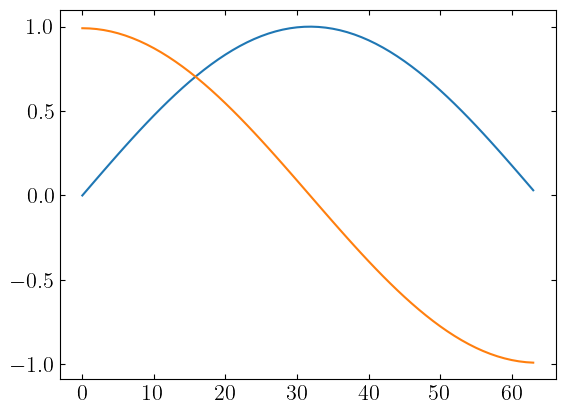

In [55]:
plt.plot(u[0,:,0], label='Input u(t)')
plt.plot(y[0,:,0], label='Target y(t)')

In [96]:
from torch.utils.data import DataLoader, TensorDataset

N, T = 1024, 64

u = np.zeros((N, 1,T))
y = np.zeros((N,1, T))
for i in trange(N):
    w = random.uniform(0.5, 10.0)
    u[i,0,:] = np.sin(w * np.linspace(0, 3.14, T))
    y[i,0,:] = w*np.cos(w * np.linspace(0, 3.14, T))


print(u.shape, y.shape  )

dataset = TensorDataset(torch.tensor(u, dtype=torch.float32), 
                        torch.tensor(y, dtype=torch.float32))

loader = DataLoader(dataset, batch_size=32, shuffle=True)

u_batch, y_batch = next(iter(loader))
print(u_batch.shape)  # should be [32, 64, 1]


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 10

for epoch in trange(epochs):
    for u_batch, y_batch in loader:  # u_batch: [B, T, 1]
        y_pred = model(u_batch)
        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

100%|██████████| 1024/1024 [00:00<00:00, 70987.67it/s]


(1024, 1, 64) (1024, 1, 64)
torch.Size([32, 1, 64])


100%|██████████| 10/10 [00:33<00:00,  3.35s/it]


In [100]:
u_test = np.zeros((1, 1,T))
y_test = np.zeros((1, 1,T))
w_test =  5# This is in the training range (0.5 to 2.0)

u_test[0,0,:] = np.sin(w_test * np.linspace(0, 3.14, T))  # w=1.5 is in the training range
y_test[0,0,:] = w_test * np.cos(w_test * np.linspace(0, 3.14, T))

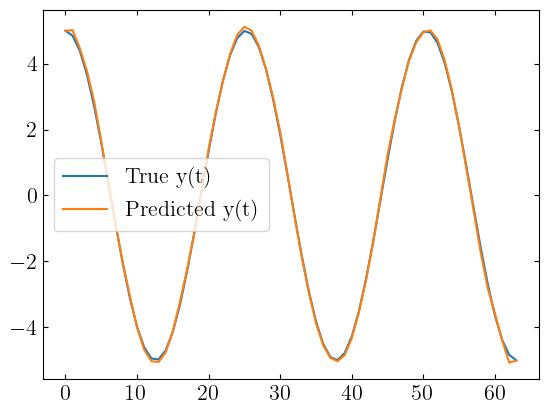

In [ ]:
y_pred = model(torch.tensor(u_test, dtype=torch.float32))
plt.plot(y_test[0,0,:], label='True $y(t)$')
plt.plot(y_pred[0,0,:].detach().numpy(), label='Predicted $y(t)$')
plt.legend()
plt.show()